In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Filemaker_CLEAN.csv")
df.head()

,experience_id,imported_class_year,imported_program,imported_unit,major_department,major_unit,notes,person_id,record_id,registrar_class_year,...,registrar_department.1,registrar_program,registrar_type,registrar_unit.1,term_season,year,student_name,class_year,term_num,student_id
0,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi,Sophomore,2,415.0
1,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi,Sophomore,2,415.0
2,4122.0,Senior,"[""Dance""]","Undergrad Music, Thtre & Dance",Dance Dance,"Music, Theatre & Dance Music, Theatre & Dance",archive april 2019,415.0,14905.0,Alumnus,...,Dance,Dance BFA,Major,"Music, Theatre & Dance",WN,2021,Abby Niemi,Senior,1,415.0
3,4122.0,Senior,"[""Dance""]","Undergrad Music, Thtre & Dance",Dance Dance,"Music, Theatre & Dance Music, Theatre & Dance",archive april 2019,415.0,14905.0,Alumnus,...,Dance,Dance BFA,Major,"Music, Theatre & Dance",WN,2021,Abby Niemi,Senior,1,415.0
4,3352.0,Freshman,"[""Theatre""]","Undergrad Music, Thtre & Dance",Theatre & Drama,"Music, Theatre & Dance",archive 2018,416.0,9947.0,Freshman,...,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2017,Alix Curnow,Freshman,2,416.0


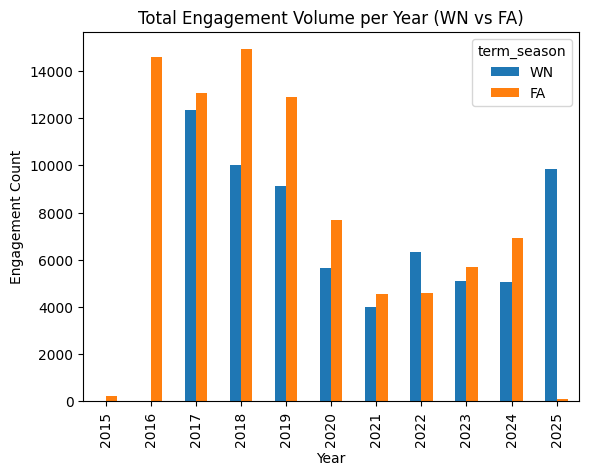

In [ ]:
# -- Total Engagement Volume Per Year --

engagements = (
    df.groupby(["year", "term_season"])["experience_id"]
    .count()
    .reset_index(name="count")
)

pivot = engagements.pivot(index="year", columns="term_season", values="count").fillna(0)
pivot = pivot.reindex(columns=["WN", "FA"], fill_value=0)

pivot.plot(kind='bar')
plt.title("Total Engagement Volume per Year (WN vs FA)")
plt.xlabel("Year")
plt.ylabel("Engagement Count")
plt.show()

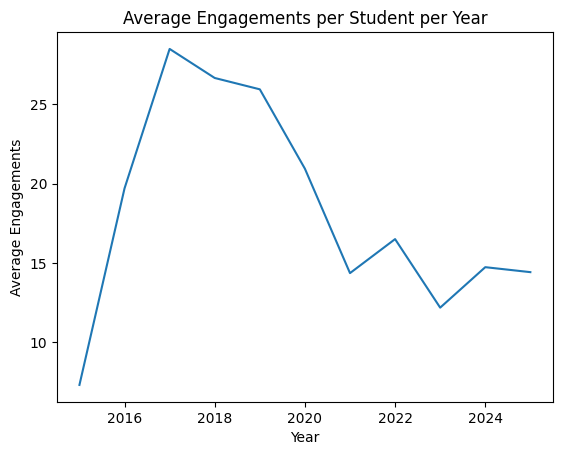

In [10]:
# -- Average Engagements per Student per Year --

per_student_year = (
    df.groupby(["year", "student_id"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

avg_per_year = per_student_year.groupby("year")["engagements"].mean()

plt.figure()
avg_per_year.plot()
plt.title("Average Engagements per Student per Year")
plt.xlabel("Year")
plt.ylabel("Average Engagements")
plt.show()

<Figure size 640x480 with 0 Axes>

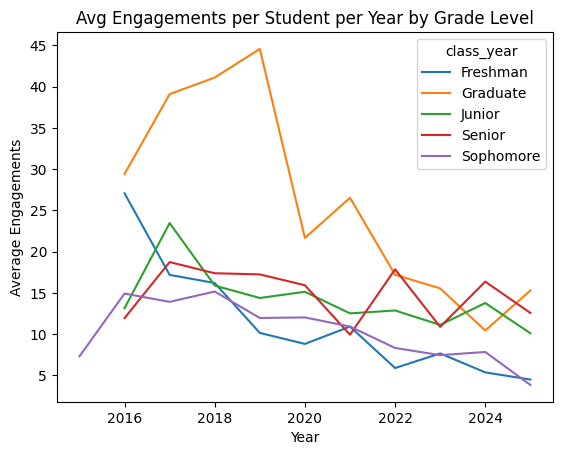

In [11]:
# -- Avg Engagements per Student per Year by Grade Level -- 
per_student_year_class = (
    df.groupby(["year", "student_id", "class_year"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

avg_by_class = (
    per_student_year_class
    .groupby(["year", "class_year"])["engagements"]
    .mean()
    .unstack()
)

plt.figure()
avg_by_class.plot()
plt.title("Avg Engagements per Student per Year by Grade Level")
plt.xlabel("Year")
plt.ylabel("Average Engagements")
plt.show()

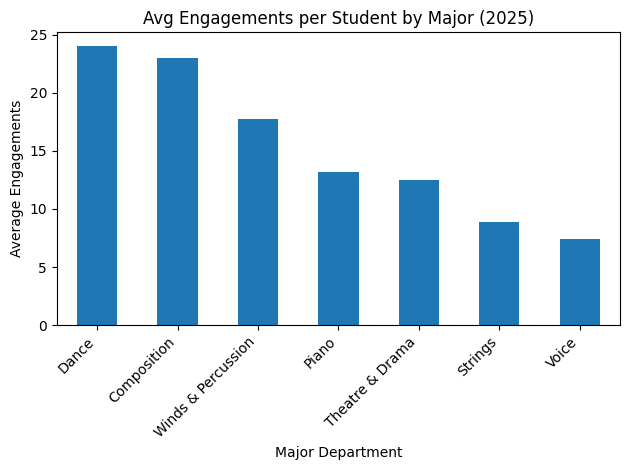

In [12]:
# Step 1: filter majors with > 1000 occurrences (across full dataset)
valid_majors = (
    df["major_department"]
    .value_counts()
    .loc[lambda x: x > 3000]
    .index
)

# Step 2: filter for 2025 + valid majors
df_2025 = df[
    (df["year"] == 2025) &
    (df["major_department"].isin(valid_majors))
]

# Step 3: engagements per student per major
per_student_major = (
    df_2025.groupby(["student_id", "major_department"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

# Step 4: average engagements per major
avg_by_major_2025 = (
    per_student_major
    .groupby("major_department")["engagements"]
    .mean()
    .sort_values(ascending=False)
)

# Step 5: bar chart
plt.figure()
avg_by_major_2025.plot(kind="bar")
plt.title("Avg Engagements per Student by Major (2025)")
plt.xlabel("Major Department")
plt.ylabel("Average Engagements")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

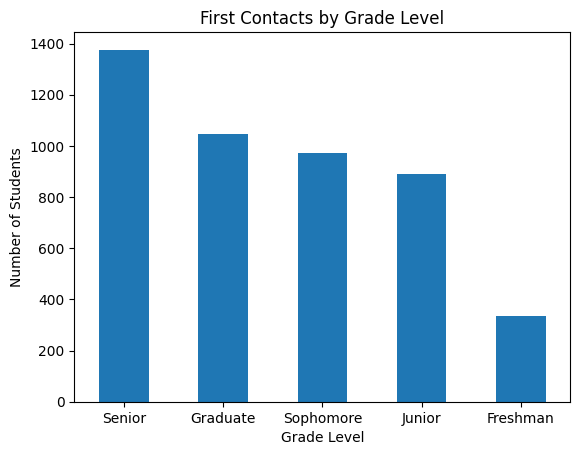

In [ ]:
# First engagement per student
first_contact = (
    df.groupby("student_id")[["year", "term_num", "class_year"]]
    .first()
    .reset_index()
)

first_counts = first_contact["class_year"].value_counts()

plt.figure()
first_counts.plot(kind="bar")
plt.title("First Contacts by Grade Level")
plt.xlabel("Grade Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

# **Homework**

Implement the graphs below:

In [ ]:
# include a graph showing percent of students who have only one event, only two events, 2+ events


In [ ]:
# include a graph showing engagements per year by event type

In [ ]:
# 